# Évaluation multicatégorielle : Qdrant et recherche classique TF-IDF

Cette expérimentation compare la recherche vectorielle Qdrant à une recherche classique TF-IDF. Elle mesure Recall@10, MRR@10 et le temps moyen sur 90 requêtes tests, réparties entre les neuf catégories de la collection équilibrée de 900 documents.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
RESULTS_DIR = PROJECT_ROOT / 'evaluation' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Projet : {PROJECT_ROOT}')

Projet : /Users/joelkouraogo/Desktop/Master 2 IBAM ISIE Soutenance 2026/Projet/projet_vectoriel


In [2]:
from evaluation.evaluate_classical_baseline import main as executer_reference_classique

# La référence TF-IDF est recalculée dans cette exécution du notebook.
executer_reference_classique()

# Les résultats Qdrant sont ceux produits par l'exécution Qdrant du même protocole.
qdrant_summary = pd.read_csv(RESULTS_DIR / 'balanced_collection_summary_metrics.csv')
qdrant_summary.insert(0, 'Méthode', 'Qdrant')
tfidf_summary = pd.read_csv(RESULTS_DIR / 'classical_baseline_summary_metrics.csv')
comparison_summary = pd.concat([qdrant_summary, tfidf_summary], ignore_index=True)
comparison_summary.to_csv(RESULTS_DIR / 'comparison_qdrant_tfidf_summary.csv', index=False)
print('Résultats combinés enregistrés dans :', RESULTS_DIR / 'comparison_qdrant_tfidf_summary.csv')

Référence classique TF-IDF :
Méthode    Scénario  Recall@10   MRR@10  Temps (ms)
 TF-IDF Avec filtre   0.988889 0.872963    0.667436
 TF-IDF Sans filtre   0.988889 0.872963    1.232592
Résultats combinés enregistrés dans : /Users/joelkouraogo/Desktop/Master 2 IBAM ISIE Soutenance 2026/Projet/projet_vectoriel/evaluation/results/comparison_qdrant_tfidf_summary.csv


In [3]:
summary = pd.read_csv(RESULTS_DIR / 'comparison_qdrant_tfidf_summary.csv')
manifest = json.loads((RESULTS_DIR / 'balanced_collection_summary.json').read_text())
print(f"Collection : {manifest['collection']}")
print(f"Documents : {manifest['document_count']} ; requêtes tests : 90")
print('Documents par catégorie :', manifest['categories'])
print('Les données affichées ci-dessous proviennent de la sortie de ce notebook.')
summary.sort_values(['Méthode', 'Scénario'])

Collection : experiment_multicategory_900
Documents : 900 ; requêtes tests : 90
Documents par catégorie : {'Actualités': 100, 'Actualités internationales': 100, 'Droit et réglementation': 100, 'FQuADRetrieval': 100, 'Mémoire académique': 100, 'Santé et recherche biomédicale': 100, 'Sciences et technologies': 100, 'Sport': 100, 'Économie et entreprises': 100}
Les données affichées ci-dessous proviennent de la sortie de ce notebook.


,Méthode,Scénario,Recall@10,MRR@10,Temps (ms)
0,Qdrant,Avec filtre,0.922222,0.791817,5.505942
1,Qdrant,Sans filtre,0.900000,0.779272,4.791232
2,TF-IDF,Avec filtre,0.988889,0.872963,0.667436
3,TF-IDF,Sans filtre,0.988889,0.872963,1.232592


In [4]:
comparison = summary.pivot(index='Méthode', columns='Scénario', values=['Recall@10', 'MRR@10', 'Temps (ms)'])
comparison

Recall@10                  MRR@10              Temps (ms)  \
Scénario Avec filtre Sans filtre Avec filtre Sans filtre Avec filtre   
Méthode                                                                
Qdrant      0.922222    0.900000    0.791817    0.779272    5.505942   
TF-IDF      0.988889    0.988889    0.872963    0.872963    0.667436   

                      
Scénario Sans filtre  
Méthode               
Qdrant      4.791232  
TF-IDF      1.232592

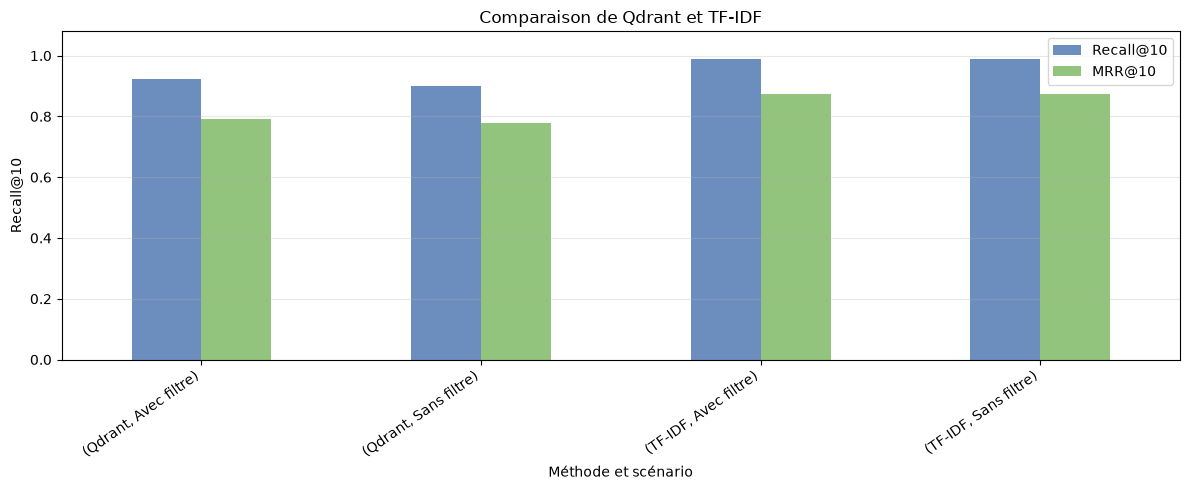

In [5]:
quality = summary.set_index(['Méthode', 'Scénario'])[['Recall@10', 'MRR@10']]
ax = quality.plot.bar(figsize=(12, 5), ylim=(0, 1.08), color=['#6c8ebf', '#93c47d'])
ax.set_title('Comparaison de Qdrant et TF-IDF')
ax.set_xlabel('Méthode et scénario')
ax.set_ylabel('Recall@10')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Les fichiers `comparison_qdrant_tfidf_summary.csv` et `classical_baseline_summary_metrics.csv` contiennent les valeurs affichées par ce notebook. Ils alimentent la comparaison présentée dans le chapitre 4.
